<a href="https://colab.research.google.com/github/nikhil123232344-eng/E23CSEU0900_Group7_CSET343/blob/main/lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub opencv-python scikit-image seaborn

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to:
/kaggle/input/chest-xray-pneumonia


In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to:
/kaggle/input/chest-xray-pneumonia


In [ ]:
dataset_path = os.path.join(path, "chest_xray")

print("Dataset path:", dataset_path)
print("Folders:", os.listdir(dataset_path))

Dataset path: /kaggle/input/chest-xray-pneumonia/chest_xray
Folders: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
for folder in ["train", "test", "val"]:
    folder_path = os.path.join(dataset_path, folder)
    print("\n", folder)

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            print(class_name, ":", len(os.listdir(class_path)))


 train
PNEUMONIA : 3875
NORMAL : 1341

 test
PNEUMONIA : 390
NORMAL : 234

 val
PNEUMONIA : 8
NORMAL : 8


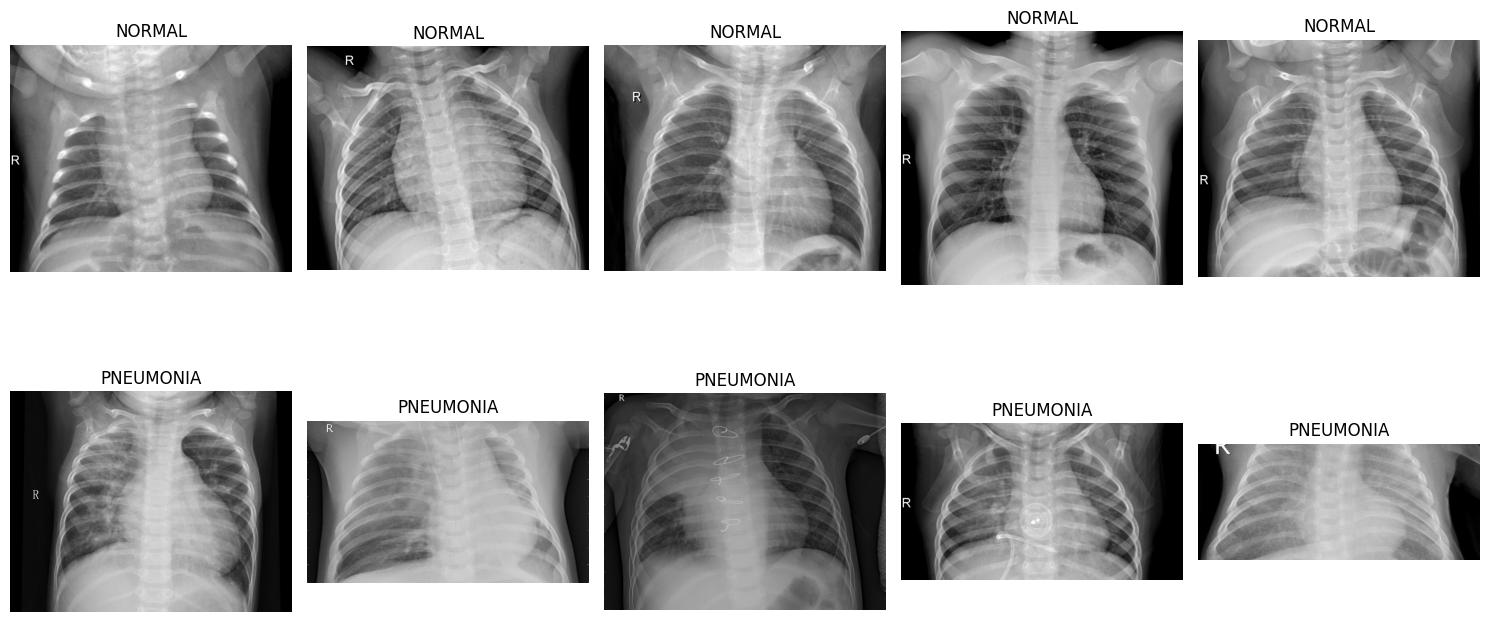

In [ ]:
import random
from PIL import Image

classes = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(15, 8))

for row, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, "train", class_name)
    images = os.listdir(class_path)

    selected_images = random.sample(images, 5)

    for col, image_name in enumerate(selected_images):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        plt.subplot(2, 5, row * 5 + col + 1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
        plt.title(class_name)

plt.tight_layout()
plt.show()

In [ ]:
for class_name in classes:
    class_path = os.path.join(dataset_path, "train", class_name)
    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)
    image = Image.open(image_path)

    print(class_name)
    print("Image size:", image.size)
    print("Mode:", image.mode)
    print()

NORMAL
Image size: (1336, 1128)
Mode: L

PNEUMONIA
Image size: (1024, 712)
Mode: L



In [ ]:
IMG_SIZE = 128

images = []
labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for split in ["train", "test", "val"]:
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, split, class_name)

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is not None:
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

                images.append(image)
                labels.append(label)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Total images:", len(images))

Images shape: (5856, 128, 128)
Labels shape: (5856,)
Total images: 5856


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 4099
Validation images: 878
Testing images: 879


In [ ]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training range:", X_train.min(), "to", X_train.max())
print("Validation range:", X_val.min(), "to", X_val.max())
print("Testing range:", X_test.min(), "to", X_test.max())

Training range: 0.0 to 1.0
Validation range: 0.0 to 1.0
Testing range: 0.0 to 1.0


In [ ]:
from skimage.feature import hog

def extract_hog(image):
    return hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

# Extract HOG features from a small sample first
hog_features = np.array([
    extract_hog(img) for img in X_train[:100]
])

print("HOG feature shape:", hog_features.shape)

HOG feature shape: (100, 1764)


In [ ]:
from skimage.feature import local_binary_pattern

def extract_lbp(image):
    image_uint8 = (image * 255).astype(np.uint8)

    radius = 1
    points = 8 * radius

    lbp = local_binary_pattern(
        image_uint8,
        points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points + 3),
        range=(0, points + 2)
    )

    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-7)

    return hist

lbp_features = np.array([
    extract_lbp(img) for img in X_train[:100]
])

print("LBP feature shape:", lbp_features.shape)

LBP feature shape: (100, 10)


In [ ]:
from skimage.feature import graycomatrix, graycoprops

def extract_glcm(image):
    image_uint8 = (image * 255).astype(np.uint8)

    # Reduce gray levels to make GLCM computation faster
    image_small = (image_uint8 // 32).astype(np.uint8)

    glcm = graycomatrix(
        image_small,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    features = [
        graycoprops(glcm, "contrast")[0, 0],
        graycoprops(glcm, "dissimilarity")[0, 0],
        graycoprops(glcm, "homogeneity")[0, 0],
        graycoprops(glcm, "energy")[0, 0],
        graycoprops(glcm, "correlation")[0, 0]
    ]

    return features

glcm_features = np.array([
    extract_glcm(img) for img in X_train[:100]
])

print("GLCM feature shape:", glcm_features.shape)

GLCM feature shape: (100, 5)


In [ ]:
# Add channel dimension for CNN

X_train_cnn = X_train.reshape(-1, 128, 128, 1)
X_val_cnn = X_val.reshape(-1, 128, 128, 1)
X_test_cnn = X_test.reshape(-1, 128, 128, 1)

print("Training shape:", X_train_cnn.shape)
print("Validation shape:", X_val_cnn.shape)
print("Testing shape:", X_test_cnn.shape)

Training shape: (4099, 128, 128, 1)
Validation shape: (878, 128, 128, 1)
Testing shape: (879, 128, 128, 1)


In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_cnn, y_val)
)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8200 - loss: 0.4115 - val_accuracy: 0.9294 - val_loss: 0.1936
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9173 - loss: 0.2070 - val_accuracy: 0.9374 - val_loss: 0.1688
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9349 - loss: 0.1718 - val_accuracy: 0.9374 - val_loss: 0.1549
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9407 - loss: 0.1555 - val_accuracy: 0.9396 - val_loss: 0.1362
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9463 - loss: 0.1400 - val_accuracy: 0.9408 - val_loss: 0.1510
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9541 - loss: 0.1269 - val_accuracy: 0.9533 - val_loss: 0.1196
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9617 - loss: 0.1096 - val_accuracy: 0.9465 - val_loss: 0.1400
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9583 - loss: 0.1089 - val_accu

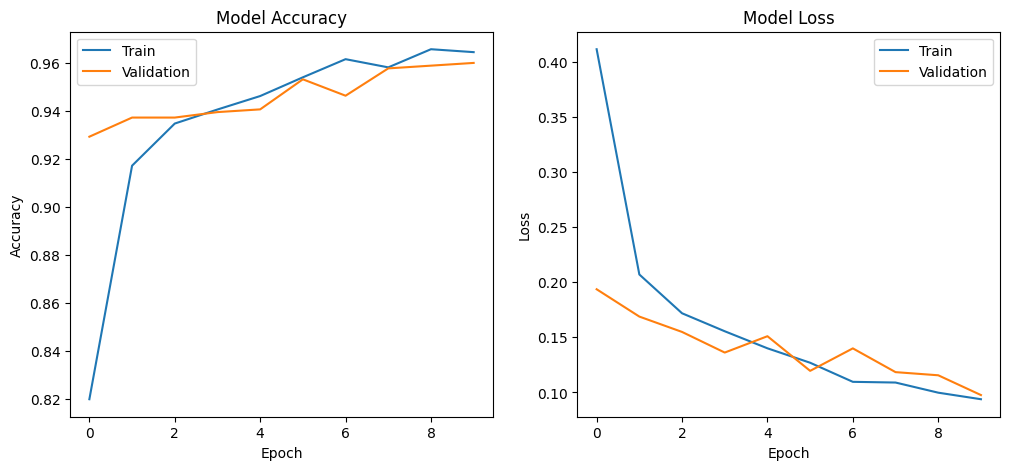

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
y_prob = model.predict(X_test_cnn)

y_pred = (y_prob > 0.5).astype(int)

print(y_pred[:10])

28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]]


In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("AUROC    :", auc)

Accuracy : 0.9590443686006825
Precision: 0.9632465543644717
Recall   : 0.9812792511700468
F1 Score : 0.9721792890262752
AUROC    : 0.9897678260071581


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.95      0.90      0.92       238
   PNEUMONIA       0.96      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.96      0.94      0.95       879
weighted avg       0.96      0.96      0.96       879



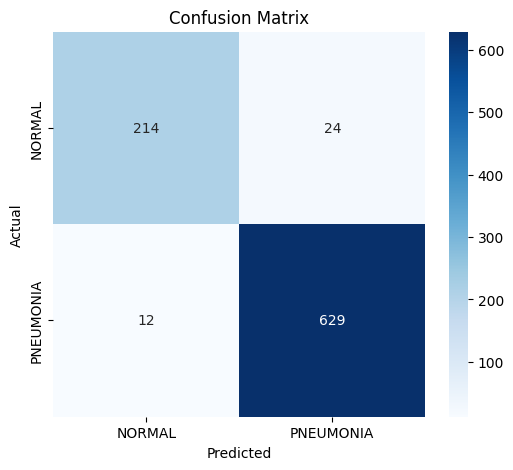

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 214
False Positive: 24
False Negative: 12
True Positive : 629


Total misclassified images: 36


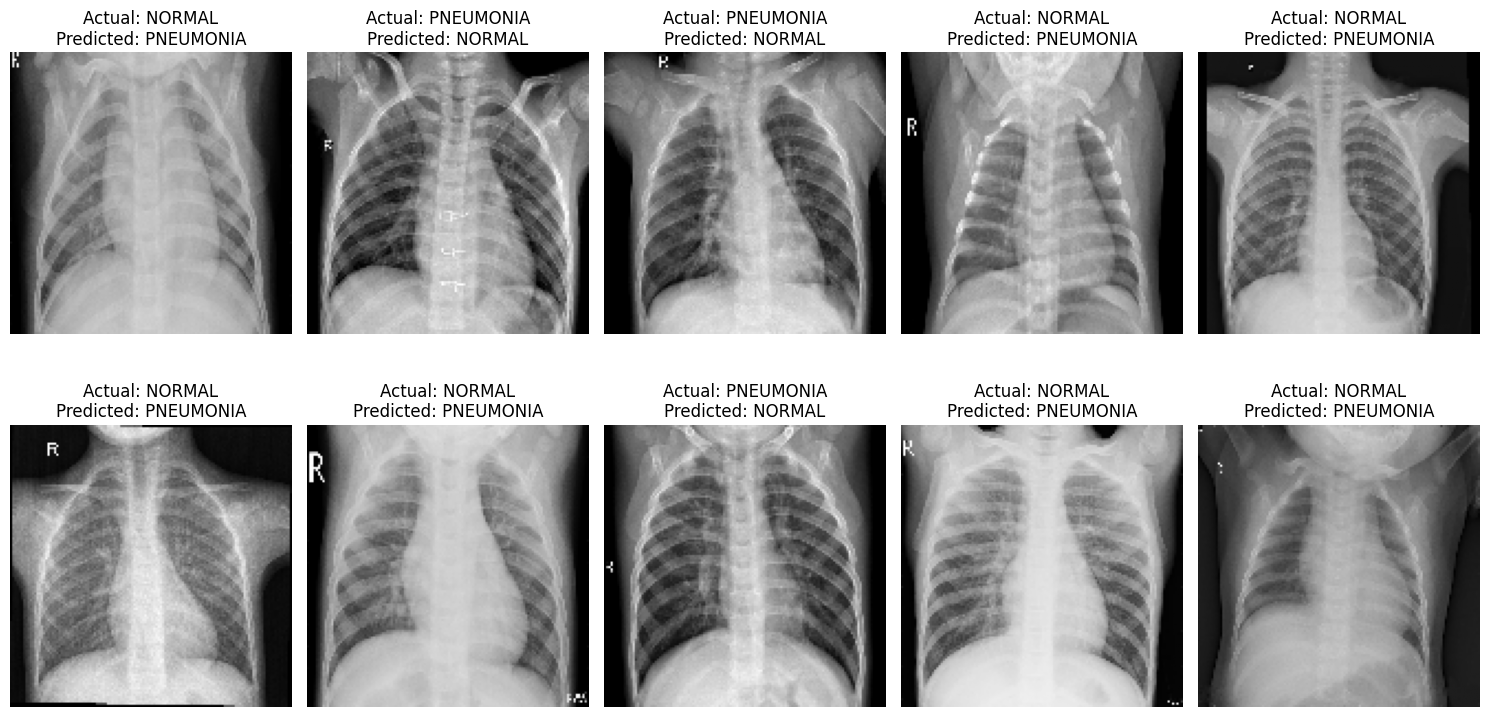

In [ ]:
wrong_indices = np.where(y_test != y_pred.flatten())[0]

print("Total misclassified images:", len(wrong_indices))

plt.figure(figsize=(15, 8))

num_images = min(10, len(wrong_indices))

for i in range(num_images):
    idx = wrong_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")

    actual = class_names[y_test[idx]]
    predicted = class_names[y_pred[idx][0]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Total misclassified images: 36


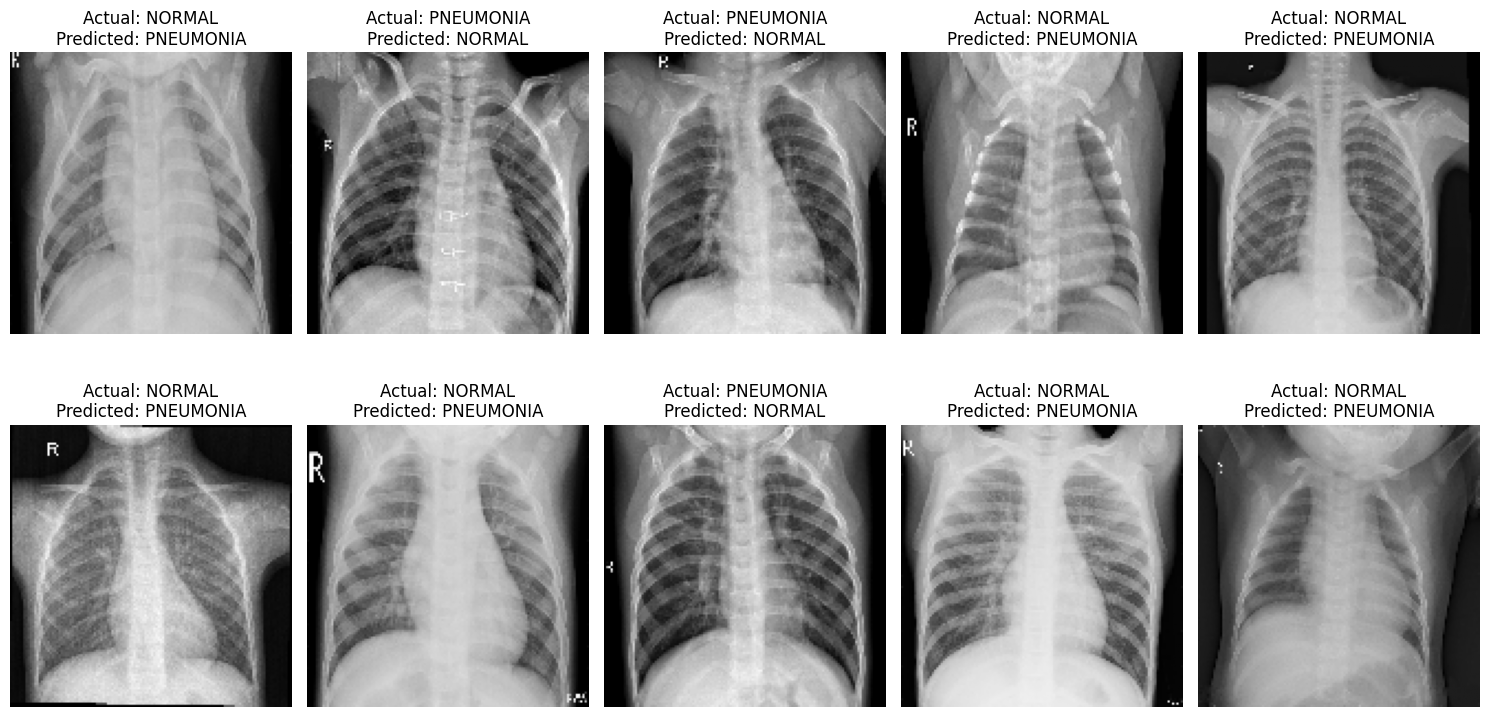

In [ ]:
wrong_indices = np.where(y_test != y_pred.flatten())[0]

print("Total misclassified images:", len(wrong_indices))

plt.figure(figsize=(15, 8))

num_images = min(10, len(wrong_indices))

for i in range(num_images):
    idx = wrong_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")

    actual = class_names[y_test[idx]]
    predicted = class_names[y_pred[idx][0]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("chest_xray_cnn_model.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUROC"
    ],
    "Score": [
        acc,
        prec,
        rec,
        f1,
        auc
    ]
})

print(results)

      Metric     Score
0   Accuracy  0.959044
1  Precision  0.963247
2     Recall  0.981279
3   F1 Score  0.972179
4      AUROC  0.989768


In [ ]:
print("========== CNN FINAL RESULTS ==========")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auc:.4f}")

========== CNN FINAL RESULTS ==========
Accuracy : 0.9590
Precision: 0.9632
Recall   : 0.9813
F1 Score : 0.9722
AUROC    : 0.9898


In [ ]:
metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "AUROC": auc
}

best_metric = max(metrics, key=metrics.get)

print("Highest numerical metric:", best_metric)
print("Score:", metrics[best_metric])

Highest numerical metric: AUROC
Score: 0.9897678260071581


In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Use a smaller subset for hyperparameter tuning
tune_size = 1200

X_tune = X_train_cnn[:tune_size]
y_tune = y_train[:tune_size]

print("Images used for tuning:", len(X_tune))

Images used for tuning: 1200


In [39]:
from tensorflow.keras import backend as K

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tune, y_tune), 1):

    print("Training Fold:", fold)

    K.clear_session()

    cv_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu",
                      input_shape=(128, 128, 1)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    cv_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    cv_model.fit(
        X_tune[train_idx],
        y_tune[train_idx],
        epochs=3,
        batch_size=32,
        verbose=0
    )

    predictions = cv_model.predict(
        X_tune[val_idx],
        verbose=0
    )

    predictions = (predictions > 0.5).astype(int)

    score = accuracy_score(
        y_tune[val_idx],
        predictions
    )

    cv_scores.append(score)

    print("Fold accuracy:", score)

Training Fold: 1


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold accuracy: 0.88
Training Fold: 2


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold accuracy: 0.9075
Training Fold: 3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold accuracy: 0.9425


In [42]:
print("\n========== CROSS-VALIDATION RESULTS ==========")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")


========== CROSS-VALIDATION RESULTS ==========
Fold 1 Accuracy: 0.8800
Fold 2 Accuracy: 0.9075
Fold 3 Accuracy: 0.9425

Mean CV Accuracy: 0.9100
